# Where the non-SNP GEA hits land — SV hits, and small indels for comparison

**What this is.** A description of the GEA's own hits: what kind of variant they are, and where
in the genome they sit, each set against **everything the GEA tested** (the right background:
only variants common enough to test can become hits).

**Hits.** The GEA's own call, as in `genes/convergence/build_gea_pool.py`: raw LFMM p-values
(gen 9, 22 climate axes = bio1–19 + pc1–3), per class × axis MAF > 0.05, Bonferroni at
0.05 / records tested; a record is a hit if it clears that bar on **any** axis in any of the
three class scans (SV, small indel, and the two pooled). Nothing is re-estimated here.

**Classes and types.** *SV* = the record is in the SV scan (≥ 50 bp); *small indel* otherwise.
*Deletion* = REF longer than ALT, *insertion* = ALT longer, both relative to Col-0 (not to the
ancestral state). Equal-length MNPs are neither and are set aside, counted in section 0.

**Regions.** The same classifier the candidate pool uses
(`genes/dissection/screen_sig_blocks.classify`), run on every tested record
(`annotate_gea_universe.py`). First match wins, gene body before promoter:
CDS > UTR / non-coding exon > intron > **promoter (≤ 1 kb upstream of a TSS, strand-aware, outside
any gene body)** > reference TE > intergenic (proximal) > gene desert.

**Unit.** One row per variant record, as the GEA tests it — so one SV can appear as several
records (arch3 splits it per assembly path); see `sv_purging_fixed.ipynb` for why the burden and
purging work collapses those into events. Split records at identical position and lengths are
collapsed here, keeping the record the GEA called (2,938 hits, as in the candidate pool).

**Enrichment.** For a region *R*: the odds that a variant in *R* is a hit, over the odds for a
variant outside *R*, Mantel–Haenszel over size-bin × MAF-bin strata (hits skew common and
towards particular sizes, so an unadjusted share would mislead), with 95% CIs from resampling
the GEA's LD blocks — hits cluster in blocks, so records are not independent.

In [1]:
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
CONV = os.path.abspath("../genes/convergence"); sys.path.insert(0, CONV)
import plot_theme as TH
import gea_region_by_axis as GR          # or_with_ci (MH + block bootstrap), size / MAF bins
TH.apply()
PLOTS = os.path.abspath("plots/gea_hit_landscape"); os.makedirs(PLOTS, exist_ok=True)
pd.set_option("display.width", 200); pd.set_option("display.max_rows", 400)

K4 = ["chrom", "pos", "ref_len", "alt_len"]
U = pd.read_csv(f"{CONV}/results/gea_hit_landscape.csv.gz")
n_raw = len(U)
# split records -> one; prefer the record the GEA called (its min p can be the higher of the two:
# the call may come from the SV scan, the min p here is from the pooled scan)
U = U.sort_values(["hit", "min_p"], ascending=[False, True]).drop_duplicates(K4).reset_index(drop=True)
REGION = {"1_CDS": "CDS", "2_UTR": "UTR / ncRNA exon", "4_exon_noncoding": "UTR / ncRNA exon",
          "5_intron": "intron", "3_promoter": "promoter (≤1 kb)", "6_TE": "TE",
          "7_proximal_intergenic": "intergenic", "8_gene_desert": "gene desert"}
RORDER = ["CDS", "UTR / ncRNA exon", "intron", "promoter (≤1 kb)", "TE", "intergenic", "gene desert"]
U["region"] = U.tier_1kb.map(REGION)
U["stratum"] = (pd.cut(U["size"], GR.SIZE_BINS, labels=False).astype(str) + "|"
                + pd.cut(U.MAF, GR.MAF_BINS, labels=False, include_lowest=True).astype(str))
KIND = {"deletion": "#1B9E77", "insertion": "#D95F02"}   # as in the burden notebooks
REF = TH.MUTED                                           # "all tested" is context, drawn grey
rng = np.random.default_rng(1)
print(f"{n_raw:,} tested records -> {len(U):,} after collapsing split records; "
      f"{int(U.hit.sum()):,} GEA hits (the candidate pool has 2,938)")

703,789 tested records -> 682,577 after collapsing split records; 2,938 GEA hits (the candidate pool has 2,938)


## 0 · The numbers

Tested records and GEA hits by class and type; *per 10k* is the hit rate, *blocks* the number of
distinct LD blocks the hits fall in (hits cluster, so blocks are the conservative count).

In [2]:
T = U.groupby(["cls", "kind"]).agg(tested=("hit", "size"), hits=("hit", "sum"))
T["hits per 10k tested"] = (1e4 * T.hits / T.tested).round(1)
T["hit blocks"] = U[U.hit].groupby(["cls", "kind"]).block.nunique()
T["share of class hits"] = (T.hits / T.groupby(level=0).hits.transform("sum")).round(3)
print(T.fillna(0).astype({"hit blocks": int}).to_string())
sv = U[(U.cls == "sv") & U.kind.isin(["deletion", "insertion"])].copy()
si = U[(U.cls == "smallindel") & U.kind.isin(["deletion", "insertion"])].copy()
print(f"\nSV hits: {int(sv.hit.sum())} ({int(sv[sv.hit].kind.eq('deletion').sum())} deletions, "
      f"{int(sv[sv.hit].kind.eq('insertion').sum())} insertions) in {sv[sv.hit].block.nunique()} blocks")

                      tested  hits  hits per 10k tested  hit blocks  share of class hits
cls        kind                                                                         
smallindel deletion   270321  1050                 38.8         695                0.406
           insertion  243634  1003                 41.2         680                0.388
           mnp        144565   534                 36.9         276                0.206
sv         deletion    13422   170                126.7         141                0.484
           insertion   10635   181                170.2         158                0.516



SV hits: 351 (170 deletions, 181 insertions) in 281 blocks


## 1 · What the SV hits are — size and frequency

**A–B** size of SV deletions and insertions: GEA hits (bars) against every SV of that type the
GEA tested (grey line), each as a share of its own set so the shapes compare. **C** minor allele
frequency: hits by type against all tested SVs. The enrichment tests below stratify on
frequency and size anyway, so a difference in either cannot masquerade as a regional one.

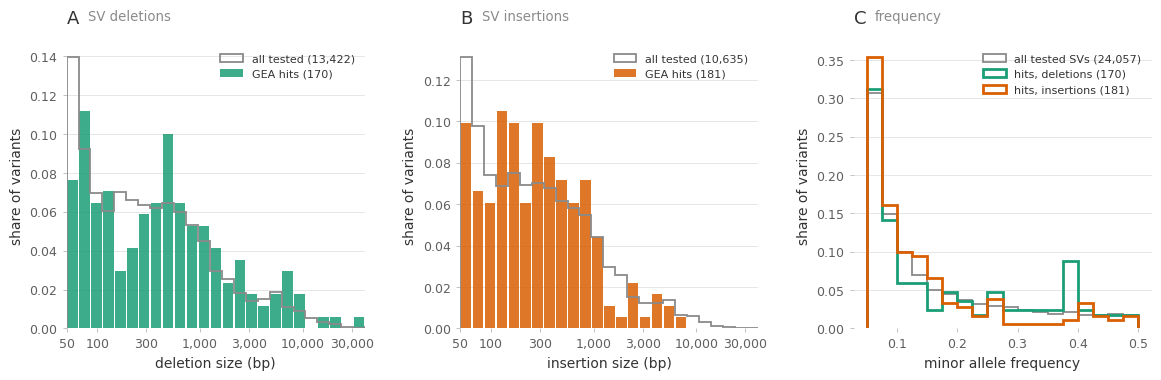

deletion  median size: hits 402 bp, tested 252 bp | median MAF: hits 0.119, tested 0.138
insertion median size: hits 270 bp, tested 236 bp | median MAF: hits 0.098, tested 0.087


In [3]:
fig, axs = plt.subplots(1, 3, figsize=(14, 3.7), gridspec_kw=dict(wspace=0.32))
bins = np.linspace(np.log10(50), np.log10(sv["size"].max()) + 0.01, 30)
tick = [50, 100, 300, 1000, 3000, 10000, 30000]
for ax, k, L in zip(axs[:2], ["deletion", "insertion"], "AB"):
    t = sv[sv.kind == k]; h = t[t.hit]
    ax.hist(np.log10(t["size"]), bins=bins, weights=np.full(len(t), 1 / len(t)), histtype="step",
            color=REF, lw=1.3, label=f"all tested ({len(t):,})")
    ax.hist(np.log10(h["size"]), bins=bins, weights=np.full(len(h), 1 / len(h)), color=KIND[k],
            alpha=0.85, rwidth=0.88, label=f"GEA hits ({len(h):,})")
    ax.set_xticks(np.log10(tick)); ax.set_xticklabels([f"{v:,}" for v in tick])
    ax.set_xlim(bins[0], min(bins[-1], np.log10(40000)))
    ax.set_xlabel(f"{k} size (bp)"); ax.set_ylabel("share of variants")
    TH.grid_only(ax, "y"); TH.panel(ax, L, f"SV {k}s", y=1.12); ax.legend(loc="upper right")
ax = axs[2]; mb = np.linspace(0.05, 0.5, 19)
ax.hist(sv.MAF, bins=mb, weights=np.full(len(sv), 1 / len(sv)), histtype="step", color=REF, lw=1.3,
        label=f"all tested SVs ({len(sv):,})")
for k in KIND:
    h = sv[sv.hit & (sv.kind == k)]
    ax.hist(h.MAF, bins=mb, weights=np.full(len(h), 1 / len(h)), histtype="step", color=KIND[k],
            lw=2, label=f"hits, {k}s ({len(h)})")
ax.set_xlabel("minor allele frequency"); ax.set_ylabel("share of variants")
TH.grid_only(ax, "y"); TH.panel(ax, "C", "frequency", y=1.12); ax.legend(loc="upper right")
plt.savefig(f"{PLOTS}/sv_hits_size_maf.png", dpi=170, bbox_inches="tight"); plt.show()
for k in KIND:
    t = sv[sv.kind == k]
    print(f"{k:9s} median size: hits {t[t.hit]['size'].median():,.0f} bp, tested {t['size'].median():,.0f} bp | "
          f"median MAF: hits {t[t.hit].MAF.median():.3f}, tested {t.MAF.median():.3f}")

## 2 · Where the SV hits land

**A–B** share of SV hits in each region (bars), deletions and insertions separately, with the
share among **all tested SVs of the same type** as a grey tick — a bar past its tick means that
region holds more of the hits than of the tested variants. *n* in each label is the hit count.
**C** the same comparison as an enrichment: Mantel–Haenszel odds ratio over size × MAF strata,
95% block-bootstrap CI, log scale; filled = CI excludes 1.

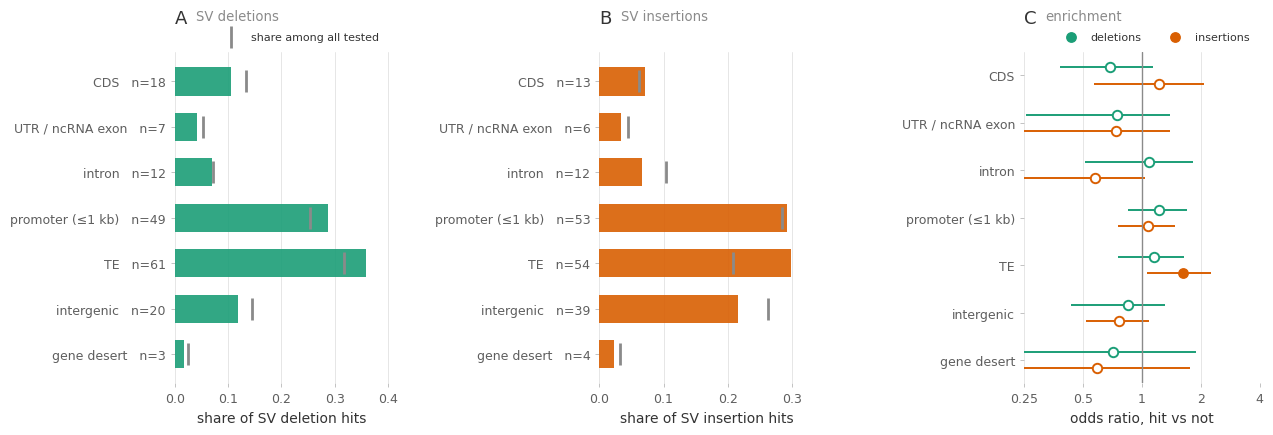

     kind           region  hits  tested  hit_share  tested_share   OR   lo   hi     p
 deletion              CDS    18    1783      0.106         0.133 0.68 0.38 1.14 0.156
 deletion UTR / ncRNA exon     7     708      0.041         0.053 0.75 0.25 1.38 0.364
 deletion           intron    12     964      0.071         0.072 1.09 0.51 1.83 0.810
 deletion promoter (≤1 kb)    49    3414      0.288         0.254 1.22 0.85 1.69 0.282
 deletion               TE    61    4266      0.359         0.318 1.16 0.75 1.64 0.470
 deletion       intergenic    20    1951      0.118         0.145 0.85 0.43 1.32 0.440
 deletion      gene desert     3     336      0.018         0.025 0.71 0.00 1.90 0.538
insertion              CDS    13     654      0.072         0.061 1.22 0.57 2.08 0.590
insertion UTR / ncRNA exon     6     481      0.033         0.045 0.74 0.24 1.39 0.370
insertion           intron    12    1109      0.066         0.104 0.58 0.25 1.03 0.062
insertion promoter (≤1 kb)    53    3027   

In [4]:
def region_stats(D):
    rows = []
    for k in KIND:
        d = D[D.kind == k]
        for r in RORDER:
            e = d.assign(_x=d.region.eq(r))
            if e._x.sum() == 0:
                continue
            o, lo, hi, p = GR.or_with_ci(e, "hit", "_x", rng)
            rows.append(dict(kind=k, region=r, hits=int((e.hit & e._x).sum()), tested=int(e._x.sum()),
                             hit_share=e[e.hit]._x.mean(), tested_share=e._x.mean(),
                             OR=o, lo=lo, hi=hi, p=p))
    return pd.DataFrame(rows)


XL = (0.25, 4.0)                      # odds-ratio axis; a CI past it is drawn to the edge


def region_figure(D, S, cls_label, fname):
    fig = plt.figure(figsize=(14, 4.3)); gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.1], wspace=0.95)
    y = np.arange(len(RORDER))
    for i, (k, L) in enumerate(zip(KIND, "AB")):
        ax = fig.add_subplot(gs[0, i]); s = S[S.kind == k].set_index("region").reindex(RORDER)
        ax.barh(y, s.hit_share, color=KIND[k], height=0.62, alpha=0.9)
        ax.scatter(s.tested_share, y, marker="|", s=260, color=REF, lw=2, zorder=3,
                   label="share among all tested")
        ax.set_yticks(y); ax.set_yticklabels([f"{r}   n={int(n) if n == n else 0}" for r, n in zip(RORDER, s.hits)])
        ax.invert_yaxis(); ax.set_xlabel(f"share of {cls_label} {k} hits")
        ax.set_xlim(0, 1.12 * np.nanmax([s.hit_share.max(), s.tested_share.max()]))
        TH.grid_only(ax, "x"); TH.panel(ax, L, f"{cls_label} {k}s", y=1.13)
        if i == 0:
            ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.0))
    ax = fig.add_subplot(gs[0, 2])
    for j, k in enumerate(KIND):
        s = S[S.kind == k].set_index("region").reindex(RORDER); off = -0.17 if j == 0 else 0.17
        ok = s.OR.notna() & (s.OR > 0)
        yy = y[ok.values] + off; ss = s[ok].copy()
        ss["lo"] = ss.lo.clip(lower=XL[0]); ss["hi"] = ss.hi.clip(upper=XL[1])   # CIs run to the edge
        sig = (ss.lo > 1) | (ss.hi < 1)
        ax.errorbar(ss.OR, yy, xerr=[ss.OR - ss.lo, ss.hi - ss.OR], fmt="none", ecolor=KIND[k], lw=1.4)
        ax.scatter(ss.OR[sig], yy[sig.values], color=KIND[k], s=46, zorder=3, label=f"{k}s")
        ax.scatter(ss.OR[~sig], yy[~sig.values], facecolor="white", edgecolor=KIND[k], s=46, lw=1.4, zorder=3)
    ax.axvline(1, color=TH.MUTED, lw=1)
    ax.set_xscale("log"); ax.set_xlim(*XL); ax.minorticks_off()
    ax.set_xticks([0.25, 0.5, 1, 2, 4]); ax.set_xticklabels(["0.25", "0.5", "1", "2", "4"])
    ax.set_yticks(y); ax.set_yticklabels(RORDER); ax.invert_yaxis()
    ax.set_xlabel("odds ratio, hit vs not")
    TH.grid_only(ax, "x"); TH.panel(ax, "C", "enrichment", y=1.13)
    ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.0), ncol=2)
    plt.savefig(f"{PLOTS}/{fname}", dpi=170, bbox_inches="tight"); plt.show()


S_sv = region_stats(sv)
region_figure(sv, S_sv, "SV", "sv_hits_by_region.png")
print(S_sv.assign(hit_share=S_sv.hit_share.round(3), tested_share=S_sv.tested_share.round(3),
                  OR=S_sv.OR.round(2), lo=S_sv.lo.round(2), hi=S_sv.hi.round(2), p=S_sv.p.round(3)).to_string(index=False))

## 3 · The same for small indels

Small indels are ~12× more numerous among the hits, so this is where the estimates are tight.
Same layout and the same statistic as section 2.

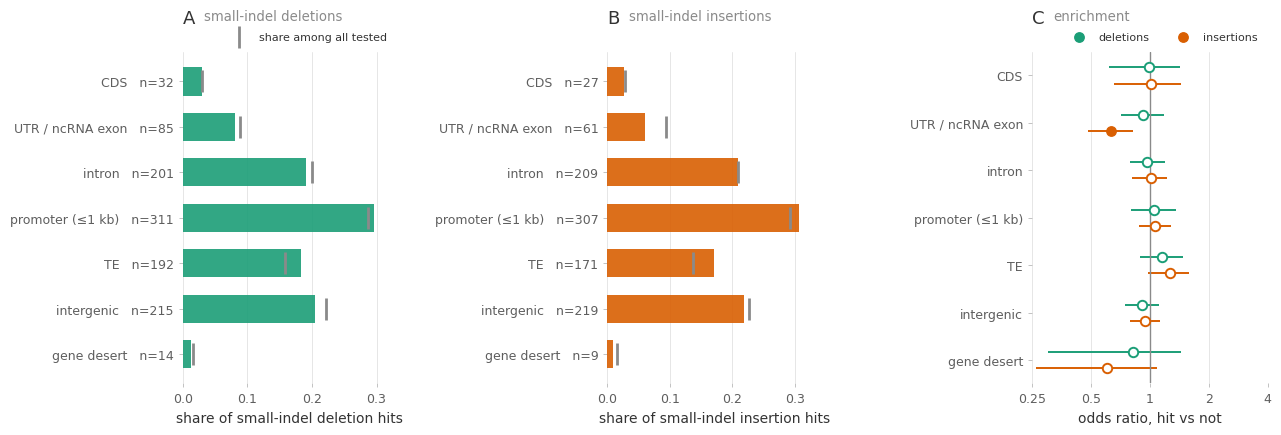

     kind           region  hits  tested  hit_share  tested_share   OR   lo   hi     p
 deletion              CDS    32    8066      0.030         0.030 0.99 0.62 1.42 0.938
 deletion UTR / ncRNA exon    85   23738      0.081         0.088 0.93 0.71 1.18 0.528
 deletion           intron   201   54086      0.191         0.200 0.96 0.79 1.20 0.694
 deletion promoter (≤1 kb)   311   77664      0.296         0.287 1.05 0.80 1.36 0.824
 deletion               TE   192   42641      0.183         0.158 1.16 0.89 1.48 0.280
 deletion       intergenic   215   59777      0.205         0.221 0.91 0.74 1.11 0.374
 deletion      gene desert    14    4349      0.013         0.016 0.82 0.30 1.43 0.462
insertion              CDS    27    6765      0.027         0.028 1.01 0.65 1.44 0.960
insertion UTR / ncRNA exon    61   22665      0.061         0.093 0.63 0.48 0.82 0.000
insertion           intron   209   50769      0.208         0.208 1.01 0.81 1.23 0.960
insertion promoter (≤1 kb)   307   71214   

In [5]:
S_si = region_stats(si)
region_figure(si, S_si, "small-indel", "smallindel_hits_by_region.png")
print(S_si.assign(hit_share=S_si.hit_share.round(3), tested_share=S_si.tested_share.round(3),
                  OR=S_si.OR.round(2), lo=S_si.lo.round(2), hi=S_si.hi.round(2), p=S_si.p.round(3)).to_string(index=False))
pd.concat([S_sv.assign(cls="sv"), S_si.assign(cls="smallindel")]).to_csv(
    f"{CONV}/results/gea_hits_region_enrichment.csv", index=False)

## 4 · Across the climate axes

For every axis with at least 20 hits (SVs and small indels together, deletions and insertions
together — split further, most cells are empty): each region's share of **that axis's** hits
divided by its share among all tested variants, on a log₂ scale. Green = more hits than the
region's size predicts, purple = fewer, grey = as expected. Cells where fewer than 3 hits are
expected are left blank: a ratio there is noise. The count after each axis name is its number
of hits. The axes are correlated with each other, so rows are not independent.

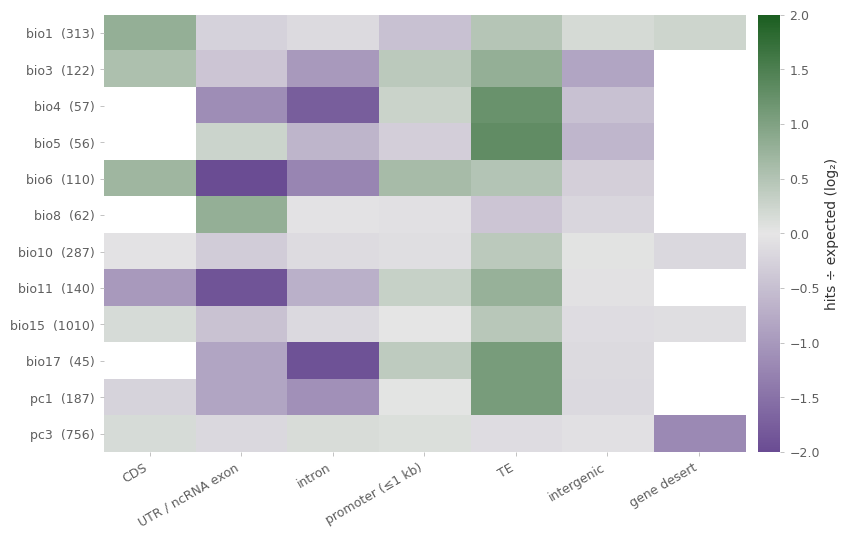

regions consistently above expectation (log2 > 0 on most axes):
CDS                 0.42
UTR / ncRNA exon    0.17
intron              0.08
promoter (≤1 kb)    0.67
TE                  0.83
intergenic          0.17
gene desert         0.08


In [6]:
A = U[U.kind.isin(["deletion", "insertion"])]
exp_share = A.region.value_counts(normalize=True).reindex(RORDER)
rows, counts = [], {}
for ax_ in GR.AXES:
    h = A[A.hit_axes.fillna("").str.split(",").map(lambda s: ax_ in s)]
    if len(h) < 20:
        continue
    counts[ax_] = len(h)
    obs = h.region.value_counts().reindex(RORDER).fillna(0); exp = exp_share * len(h)
    rows.append(np.where(exp >= 3, np.log2((obs + 0.5) / (exp + 0.5)), np.nan))
M = np.array(rows); names = list(counts)
cmap = LinearSegmentedColormap.from_list("enr", ["#6A4C93", "#E6E6E6", "#1B5E20"])
fig, ax = plt.subplots(figsize=(8.8, 0.34 * len(names) + 1.6))
im = ax.imshow(M, cmap=cmap, vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(RORDER))); ax.set_xticklabels(RORDER, rotation=30, ha="right")
ax.set_yticks(range(len(names))); ax.set_yticklabels([f"{a}  ({counts[a]})" for a in names])
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02); cb.set_label("hits ÷ expected (log₂)", color=TH.LABEL)
cb.outline.set_visible(False)
plt.savefig(f"{PLOTS}/hits_by_region_by_axis.png", dpi=170, bbox_inches="tight"); plt.show()
print("regions consistently above expectation (log2 > 0 on most axes):")
print(pd.Series((M > 0).mean(0), index=RORDER).round(2).to_string())

## 5 · Distance to the nearest transcription start site

Signed distance from each variant to the nearest TSS, in the gene's orientation (negative =
upstream). Only the ±3 kb window is drawn, but each bar is a share of the set's **total**, so the
curves also show how much of each set lies near a TSS at all (variants farther away are in no
bar). SV hits by type against all tested SVs.

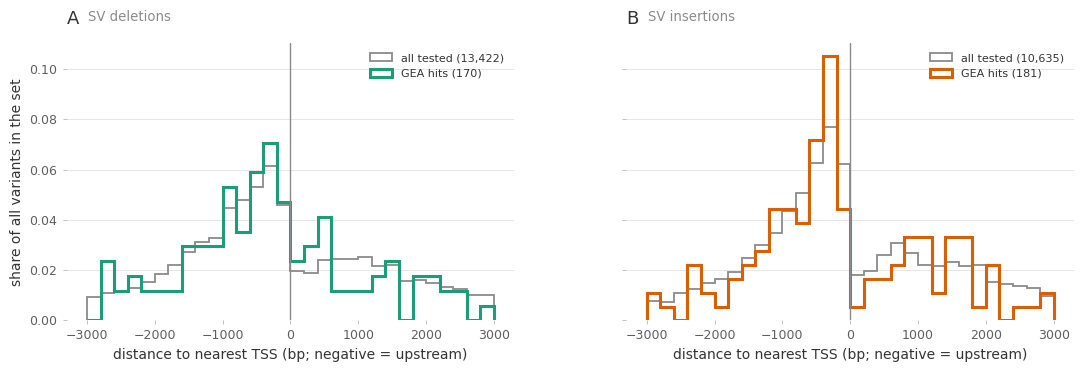

deletion  within 1 kb of a TSS: hits 0.382, tested 0.364
insertion within 1 kb of a TSS: hits 0.398, tested 0.417


In [7]:
fig, axs = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw=dict(wspace=0.25), sharey=True)
b = np.arange(-3000, 3001, 200)
for ax, k, L in zip(axs, ["deletion", "insertion"], "AB"):
    t = sv[sv.kind == k]; h = t[t.hit]
    tw, hw = t[t.dist_tss.abs() <= 3000], h[h.dist_tss.abs() <= 3000]
    ax.hist(tw.dist_tss, bins=b, weights=np.full(len(tw), 1 / len(t)), histtype="step",
            color=REF, lw=1.3, label=f"all tested ({len(t):,})")
    ax.hist(hw.dist_tss, bins=b, weights=np.full(len(hw), 1 / len(h)), histtype="step",
            color=KIND[k], lw=2.2, label=f"GEA hits ({len(h)})")
    ax.axvline(0, color=TH.MUTED, lw=1)
    ax.set_xlabel("distance to nearest TSS (bp; negative = upstream)")
    TH.grid_only(ax, "y"); TH.panel(ax, L, f"SV {k}s", y=1.12); ax.legend(loc="upper right")
axs[0].set_ylabel("share of all variants in the set")
plt.savefig(f"{PLOTS}/sv_hits_tss_distance.png", dpi=170, bbox_inches="tight"); plt.show()
for k in KIND:
    t = sv[sv.kind == k]; near = lambda d: (d.dist_tss.abs() <= 1000).mean()
    print(f"{k:9s} within 1 kb of a TSS: hits {near(t[t.hit]):.3f}, tested {near(t):.3f}")

## 6 · The SV hits, by region

Every SV hit with its region and the gene the region call is about (`gene` from the candidate
pool's classification — for a promoter, the gene whose promoter it is; for intergenic / TE /
gene desert, no host gene). Sorted by region, then by p. Also written to
`genes/convergence/results/gea_sv_hits_by_region.csv`.

In [8]:
V = pd.read_csv(f"{CONV}/results/variants_classified.csv", low_memory=False, usecols=K4 + ["gene", "nearest_gene"])
H = sv[sv.hit].merge(V.drop_duplicates(K4), on=K4, how="left")
H["host_gene"] = np.where(H.region.isin(["CDS", "UTR / ncRNA exon", "intron", "promoter (≤1 kb)"]), H.gene, "")
H["region"] = pd.Categorical(H.region, RORDER, ordered=True)
H = H.sort_values(["region", "min_p"])
cols = ["region", "kind", "size", "chrom", "pos", "host_gene", "nearest_gene", "MAF", "n_hit_axes", "hit_axes", "min_p"]
H[cols].to_csv(f"{CONV}/results/gea_sv_hits_by_region.csv", index=False)
print(H.groupby(["region", "kind"], observed=True).size().unstack(fill_value=0).to_string())
H[cols].assign(MAF=H.MAF.round(3), min_p=H.min_p.map(lambda v: f"{v:.1e}")).reset_index(drop=True)

kind              deletion  insertion
region                               
CDS                     18         13
UTR / ncRNA exon         7          6
intron                  12         12
promoter (≤1 kb)        49         53
TE                      61         54
intergenic              20         39
gene desert              3          4


,region,kind,size,chrom,pos,host_gene,nearest_gene,MAF,n_hit_axes,hit_axes,min_p
0,CDS,deletion,450,Chr3,7805120,AT3G22142,AT3G22142,0.066,2,"bio1,bio15",6.2e-12
1,CDS,insertion,312,Chr4,7204359,AT4G12020,AT4G12020,0.076,5,"bio1,bio3,bio6,bio11,pc1",1.3e-09
2,CDS,insertion,4566,Chr4,7319259,AT4G12330,AT4G12330,0.055,3,"bio1,bio10,pc3",2.7e-08
3,CDS,deletion,2353,Chr2,15326395,AT2G36540,AT2G36540,0.085,1,bio15,6.6e-08
4,CDS,insertion,4402,Chr2,5681837,AT2G13623,AT2G13623,0.052,1,pc3,8.1e-08
5,CDS,deletion,2779,Chr2,11523547,AT2G27000,AT2G27000,0.290,1,bio3,1.0e-07
6,CDS,deletion,2234,Chr4,963452,AT4G02180,AT4G02180,0.057,3,"bio4,bio6,bio7",1.5e-07
7,CDS,deletion,4710,Chr4,6589103,AT4G10695,AT4G10695,0.152,1,pc3,1.6e-07
8,CDS,deletion,904,Chr2,7923833,AT2G18200,AT2G18200,0.148,1,bio1,1.9e-07
9,CDS,deletion,599,Chr3,11965676,AT3G30370,AT3G30370,0.096,1,bio15,1.9e-07
